# Plant Disease Classification — Combined Dataset Model Comparison

Compares **6 models** trained on the unified 24-class combined dataset
(Cotton × 6 · Wheat × 3 · Potato × 3 · Bell Pepper × 2 · Tomato × 10).

| Model | Architecture Family | Type |
|---|---|---|
| **InceptionNet** | Standard GoogLeNet-style (1×1→3×3/5×5, Concat, GAP) | Baseline |
| **ResNet** | Standard Residual blocks (Conv→BN→Add shortcut, GAP) | Baseline |
| **Inception + Add** | Custom: Inception branches fused with Add | Ablation |
| **Skip + Concat** | Custom: DenseNet-style skip with Concat | Ablation |
| **Proposed 1** | Custom Hybrid: Inception(Add) + Skip(Concat) + GAP | Proposed |
| **Proposed 2** | Proposed 1 + SE Channel Attention after every block | Proposed |


In [1]:
!pip install matplotlib seaborn pandas numpy scikit-learn scipy -q
print('Ready.')


Ready.


In [2]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 140, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.framealpha': 0.9, 'legend.fontsize': 9,
})
SAVE_DIR = '/kaggle/working/comparison_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Imports ready. Outputs →', SAVE_DIR)


Imports ready. Outputs → /kaggle/working/comparison_outputs


In [3]:
import os

EXTRACT_ROOT = '/kaggle/input/datasets/jyotiradityachillal/comnbinedlogs'
print("EXTRACT_ROOT =", EXTRACT_ROOT)

# ── Model registry ────────────────────────────────────────────────────────
# (folder, nb_id, display_name, description, type)
MODELS = [
    ('NB4_logs',
     'NB4',    'InceptionNet',  'Standard InceptionNet (1×1 bottleneck → Concat → GAP)',         'Baseline'),
    ('NB5_logs',
     'NB5',    'ResNet',        'Standard ResNet (residual Add blocks → GAP)',                   'Baseline'),
    ('NB6_logs',
     'NB6',    'Inception + Add','Custom: Inception cells fused with Add (no skip conn.)',        'Ablation'),
    ('NB7_logs',
     'NB7',    'Skip + Concat', 'Custom: DenseNet-style Skip+Concat only (no inception)',        'Ablation'),
    ('complete_hybrid_logs/complete_hybrid_logs',
     'P1',     'Proposed 1',   'Custom Hybrid: Inception(Add) + Skip(Concat) + GAP',            'Proposed'),
    ('NB_A_logs',
     'P2',     'Proposed 2',   'Proposed 1 + SE Channel Attention + Cosine Warmup LR',          'Proposed'),
]

# Colours and markers — consistent across every plot in this notebook
COLORS = {
    'InceptionNet':   '#2196F3',   # blue
    'ResNet':         '#4CAF50',   # green
    'Inception + Add':'#FFC107',   # amber
    'Skip + Concat':  '#9C27B0',   # purple
    'Proposed 1':     '#FF5722',   # deep orange
    'Proposed 2':     '#E91E63',   # pink/red  ← best model, stands out
}
LINESYLES = {
    'Baseline': '-',
    'Ablation': '--',
    'Proposed': '-',
}
MARKERS = {
    'Baseline': 's',
    'Ablation': '^',
    'Proposed': 'D',
}
LINEWIDTHS = {'Baseline': 1.8, 'Ablation': 1.5, 'Proposed': 2.5}

# Convenience helpers
def color(name):  return COLORS[name]
def ls(typ):      return LINESYLES[typ]
def marker(typ):  return MARKERS[typ]
def lw(typ):      return LINEWIDTHS[typ]
def fpath(folder, fname):
    return os.path.join(EXTRACT_ROOT, folder, fname)

print(f"Registry: {len(MODELS)} models")
for fold, nb_id, name, desc, typ in MODELS:
    ok = '✓' if os.path.isdir(os.path.join(EXTRACT_ROOT,fold)) else '✗ MISSING'
    print(f"  [{ok}] {name:<18}  ({typ})  {desc}")


EXTRACT_ROOT = /kaggle/input/datasets/jyotiradityachillal/comnbinedlogs
Registry: 6 models
  [✓] InceptionNet        (Baseline)  Standard InceptionNet (1×1 bottleneck → Concat → GAP)
  [✓] ResNet              (Baseline)  Standard ResNet (residual Add blocks → GAP)
  [✓] Inception + Add     (Ablation)  Custom: Inception cells fused with Add (no skip conn.)
  [✓] Skip + Concat       (Ablation)  Custom: DenseNet-style Skip+Concat only (no inception)
  [✓] Proposed 1          (Proposed)  Custom Hybrid: Inception(Add) + Skip(Concat) + GAP
  [✓] Proposed 2          (Proposed)  Proposed 1 + SE Channel Attention + Cosine Warmup LR


## 1 · File Audit


In [4]:
EXPECTED = ['metrics_summary.csv','per_class_metrics.csv','roc_auc.csv',
            'training_history.csv','y_prob.npy','y_true.npy']
OPTIONAL = ['confusion_matrix.png','roc_curves.png','training_curves.png',
            'per_class_metrics.png','classification_report.txt']

print(f"{'Model':<18} {'Req files':>10}  {'Optional':>10}  Status")
print("─"*60)
all_ok = True
for fold, nb_id, name, desc, typ in MODELS:
    d = os.path.join(EXTRACT_ROOT, fold)
    if not os.path.isdir(d):
        print(f"  {name:<16}  FOLDER MISSING"); all_ok=False; continue
    present = set(os.listdir(d))
    req_ok  = sum(1 for f in EXPECTED  if f in present)
    opt_ok  = sum(1 for f in OPTIONAL  if f in present)
    miss    = [f for f in EXPECTED if f not in present]
    status  = '✓ OK' if not miss else f'✗ missing: {miss}'
    print(f"  {name:<16}  {req_ok}/{len(EXPECTED)}        {opt_ok}/{len(OPTIONAL)}       {status}")
    if miss: all_ok=False
print()
print("All required files present ✓" if all_ok else "⚠ Some files missing — check paths above.")


Model               Req files    Optional  Status
────────────────────────────────────────────────────────────
  InceptionNet      6/6        5/5       ✓ OK
  ResNet            6/6        5/5       ✓ OK
  Inception + Add   6/6        5/5       ✓ OK
  Skip + Concat     6/6        5/5       ✓ OK
  Proposed 1        4/6        5/5       ✗ missing: ['y_prob.npy', 'y_true.npy']
  Proposed 2        6/6        4/5       ✓ OK

⚠ Some files missing — check paths above.


## 2 · Load All Metrics


In [5]:
rows = []
for fold, nb_id, name, desc, typ in MODELS:
    p = fpath(fold, 'metrics_summary.csv')
    if not os.path.exists(p): print(f"SKIP {name}: no metrics_summary.csv"); continue
    df = pd.read_csv(p); r = df.iloc[0].to_dict()
    # Normalise recall/sensitivity column name
    if 'sensitivity' in r and 'recall' not in r: r['recall'] = r['sensitivity']
    r.update({'name':name,'type':typ,'desc':desc,'nb_id':nb_id,'folder':fold})
    rows.append(r)

metrics = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
metrics['display'] = metrics['name']   # alias used in all label code

# Pretty-print
show = ['name','accuracy','precision','recall','f1','specificity',
        'params','train_time_min','best_val_acc']
show = [c for c in show if c in metrics.columns]
fmt  = metrics[show].copy()
for col in ['accuracy','precision','recall','f1','specificity','best_val_acc']:
    if col in fmt.columns: fmt[col] = fmt[col].map('{:.4f}'.format)
if 'params' in fmt.columns:
    fmt['params'] = fmt['params'].apply(lambda x: f'{int(x):,}' if pd.notna(x) else '—')
if 'train_time_min' in fmt.columns:
    fmt['train_time_min'] = fmt['train_time_min'].map(lambda x: f'{x:.1f} min' if pd.notna(x) else '—')
fmt = fmt.rename(columns={'name':'Model','train_time_min':'Train Time',
                           'best_val_acc':'Best Val Acc'})
print("=== Master Metrics Table (sorted by Accuracy) ===")
print(fmt.to_string(index=False))
metrics.to_csv(os.path.join(SAVE_DIR,'metrics_master.csv'), index=False)
print("\nSaved → metrics_master.csv")


=== Master Metrics Table (sorted by Accuracy) ===
          Model accuracy precision recall     f1 specificity    params Train Time Best Val Acc
     Proposed 2   0.9704    0.9707 0.9704 0.9704      0.9987   949,782   83.8 min       0.9666
         ResNet   0.9604    0.9603 0.9604 0.9602      0.9983   741,720   27.9 min       0.9614
     Proposed 1   0.9591    0.9598 0.9591 0.9591      0.9982   934,200   93.3 min       0.9629
Inception + Add   0.9584    0.9584 0.9584 0.9582      0.9982   949,112   82.0 min       0.9572
  Skip + Concat   0.9567    0.9570 0.9567 0.9567      0.9981 1,139,640   63.9 min       0.9545
   InceptionNet   0.9533    0.9534 0.9533 0.9532      0.9980   270,656   59.1 min       0.9574

Saved → metrics_master.csv


## 3 · Accuracy & F1-Score


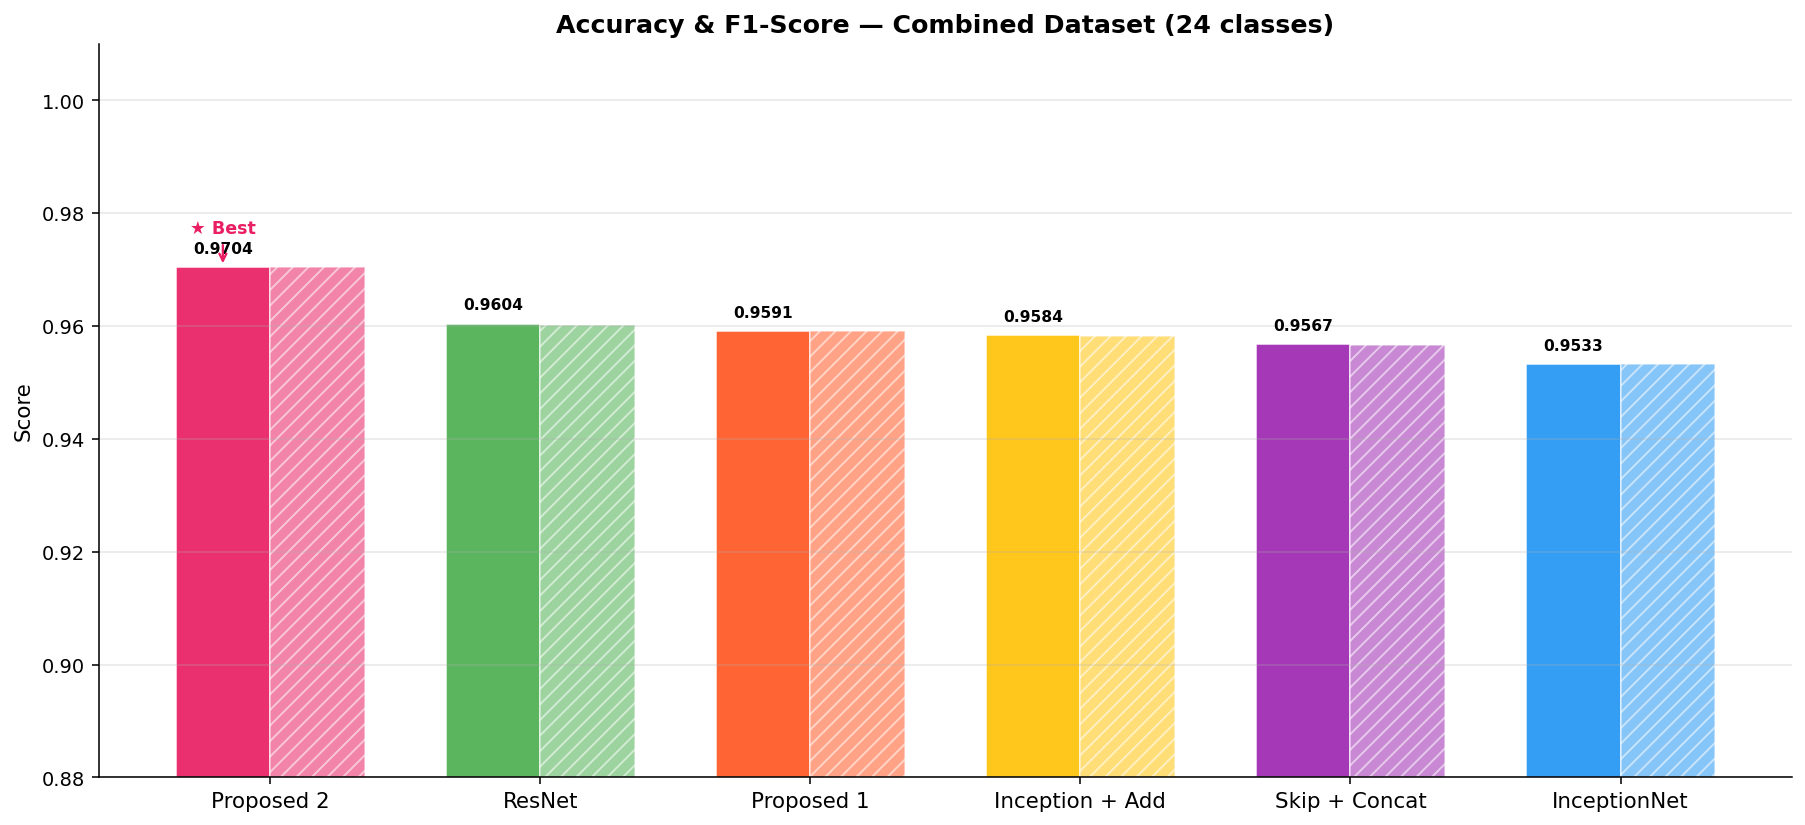

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))
names  = metrics['name'].tolist()
accs   = metrics['accuracy'].tolist()
f1s    = metrics['f1'].tolist()
types  = metrics['type'].tolist()
clrs   = [color(n) for n in names]
x      = np.arange(len(names)); w = 0.35

b_acc = ax.bar(x - w/2, accs, w, color=clrs, alpha=0.92, edgecolor='white', linewidth=0.8, label='Accuracy')
b_f1  = ax.bar(x + w/2, f1s,  w, color=clrs, alpha=0.55, edgecolor='white', linewidth=0.8, hatch='///', label='F1-Score')

# Value labels
for bar in b_acc:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Score')
ax.set_title('Accuracy & F1-Score — Combined Dataset (24 classes)', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Highlight Proposed 2 as winner
best_idx = metrics['accuracy'].idxmax()
best_x   = x[best_idx]
ax.annotate('★ Best', xy=(best_x - w/2, metrics['accuracy'].max()),
            xytext=(best_x - w/2, metrics['accuracy'].max() + 0.006),
            ha='center', fontsize=9, color='#E91E63', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.2))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'accuracy_f1.png'), dpi=140, bbox_inches='tight')
plt.show()


## 4 · Precision · Recall · Specificity


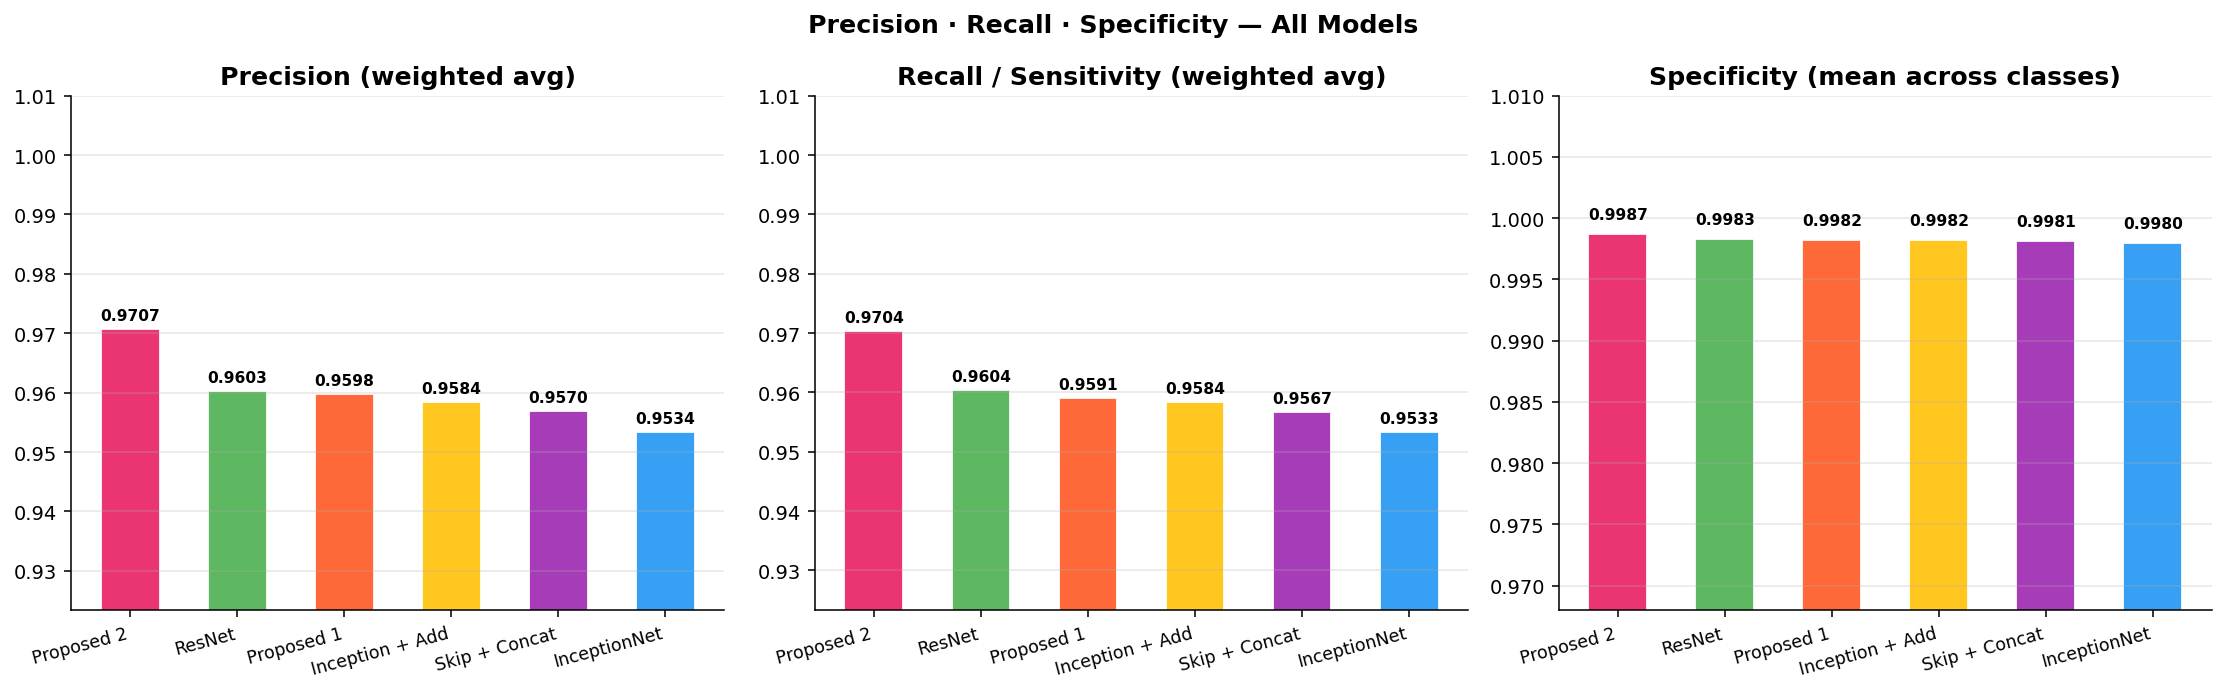

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in [
    (axes[0], 'precision',    'Precision (weighted avg)'),
    (axes[1], 'recall',       'Recall / Sensitivity (weighted avg)'),
    (axes[2], 'specificity',  'Specificity (mean across classes)'),
]:
    if col not in metrics.columns: ax.set_visible(False); continue
    vals  = metrics[col].tolist()
    clrs  = [color(n) for n in metrics['name']]
    bars  = ax.bar(metrics['name'], vals, color=clrs, edgecolor='white', width=0.55, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_ylim(max(0.85, min(vals)-0.03), 1.01)
    ax.set_xticklabels(metrics['name'], rotation=15, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold'); ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Precision · Recall · Specificity — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'prec_rec_spec.png'), dpi=140, bbox_inches='tight')
plt.show()


## 5 · ROC Curves (from raw prediction probabilities)


  Skip Proposed 1: y_prob/y_true not found


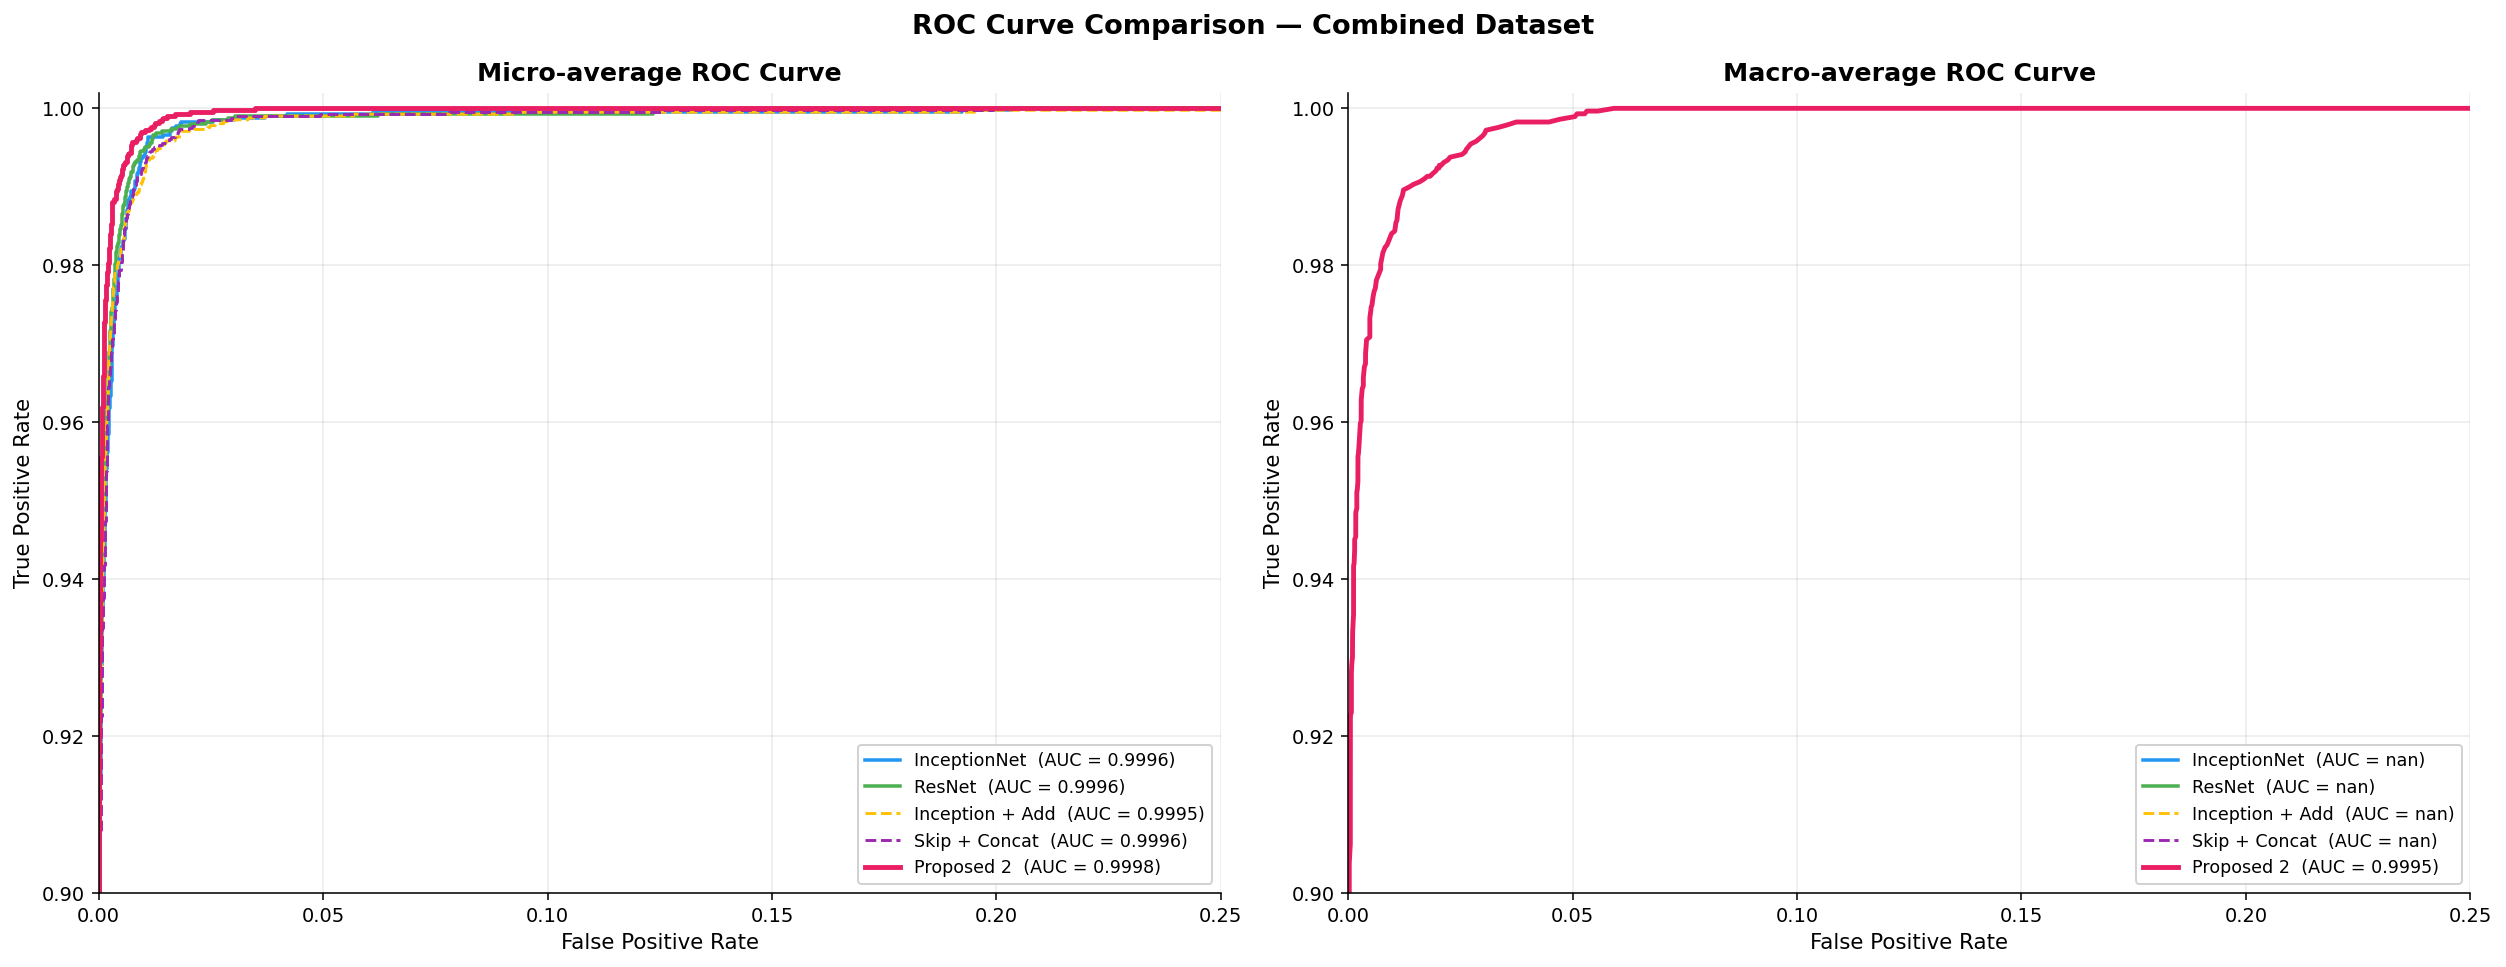

ROC AUC Summary:
          Model  Micro_AUC  Macro_AUC
     Proposed 2   0.999834   0.999452
   InceptionNet   0.999563        NaN
         ResNet   0.999622        NaN
Inception + Add   0.999488        NaN
  Skip + Concat   0.999557        NaN


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

micro_auc_vals, macro_auc_vals = {}, {}

for fold, nb_id, name, desc, typ in MODELS:
    prob_p = fpath(fold, 'y_prob.npy')
    true_p = fpath(fold, 'y_true.npy')
    if not (os.path.exists(prob_p) and os.path.exists(true_p)):
        print(f"  Skip {name}: y_prob/y_true not found"); continue
    y_prob = np.load(prob_p); y_true = np.load(true_p)
    n_cls  = y_prob.shape[1]
    y_bin  = label_binarize(y_true, classes=list(range(n_cls)))
    clr    = color(name); lstyle = ls(typ); lwidth = lw(typ)

    # Micro-average ROC
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), y_prob.ravel())
    m_auc = auc(fpr_m, tpr_m); micro_auc_vals[name] = m_auc
    axes[0].plot(fpr_m, tpr_m, color=clr, lw=lwidth, ls=lstyle,
                 label=f'{name}  (AUC = {m_auc:.4f})')

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([roc_curve(y_bin[:,i],y_prob[:,i])[0] for i in range(n_cls)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_cls):
        fi, ti, _ = roc_curve(y_bin[:,i], y_prob[:,i])
        mean_tpr += np.interp(all_fpr, fi, ti)
    mean_tpr /= n_cls
    ma_auc = auc(all_fpr, mean_tpr); macro_auc_vals[name] = ma_auc
    axes[1].plot(all_fpr, mean_tpr, color=clr, lw=lwidth, ls=lstyle,
                 label=f'{name}  (AUC = {ma_auc:.4f})')

for ax, title in [(axes[0],'Micro-average ROC Curve'), (axes[1],'Macro-average ROC Curve')]:
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.35)
    ax.set_xlim([0,0.25]); ax.set_ylim([0.90,1.002])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold'); ax.legend(loc='lower right'); ax.grid(alpha=0.25)

# Type legend
legend_elems = [
    Line2D([0],[0],color='gray',lw=2.5,ls='-', label='Baseline / Proposed — solid line'),
    Line2D([0],[0],color='gray',lw=1.8,ls='--',label='Ablation — dashed line'),
]
axes[0].legend(loc='lower right', fontsize=9)
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle('ROC Curve Comparison — Combined Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'roc_comparison.png'), dpi=140, bbox_inches='tight')
plt.show()

roc_df = pd.DataFrame({'Model': list(micro_auc_vals.keys()),
                       'Micro_AUC': list(micro_auc_vals.values()),
                       'Macro_AUC': [macro_auc_vals[k] for k in micro_auc_vals]})
roc_df.to_csv(os.path.join(SAVE_DIR,'roc_auc_summary.csv'), index=False)
print("ROC AUC Summary:")
print(roc_df.sort_values('Macro_AUC',ascending=False).to_string(index=False))


## 6 · Multi-Metric Radar Chart


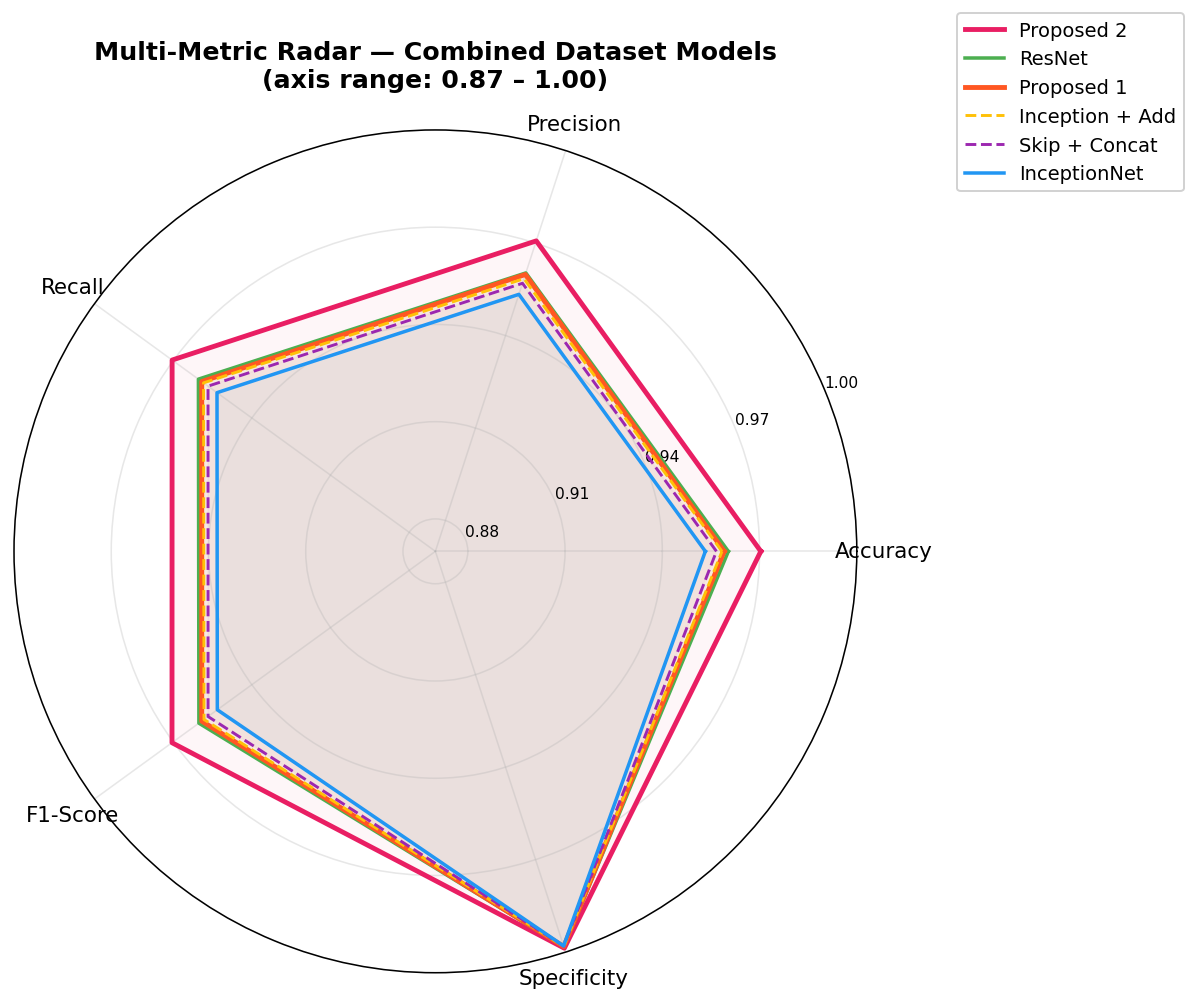

In [9]:
RADAR_METRICS = ['accuracy','precision','recall','f1','specificity']
RADAR_LABELS  = ['Accuracy','Precision','Recall','F1-Score','Specificity']
N = len(RADAR_METRICS)
angles = [n/float(N)*2*math.pi for n in range(N)]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
for _, row in metrics.iterrows():
    vals = [row.get(m, 0) for m in RADAR_METRICS]; vals += vals[:1]
    ax.plot(angles, vals, lw=lw(row['type']), ls=ls(row['type']),
            color=color(row['name']), label=row['name'])
    ax.fill(angles, vals, color=color(row['name']), alpha=0.04)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(RADAR_LABELS, fontsize=11)
ax.set_ylim(0.87, 1.0)
ax.set_yticks([0.88, 0.91, 0.94, 0.97, 1.0])
ax.set_yticklabels(['0.88','0.91','0.94','0.97','1.00'], fontsize=8)
ax.set_title('Multi-Metric Radar — Combined Dataset Models\n(axis range: 0.87 – 1.00)',
             fontweight='bold', pad=22, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'radar.png'), dpi=140, bbox_inches='tight')
plt.show()


## 7 · Training Convergence


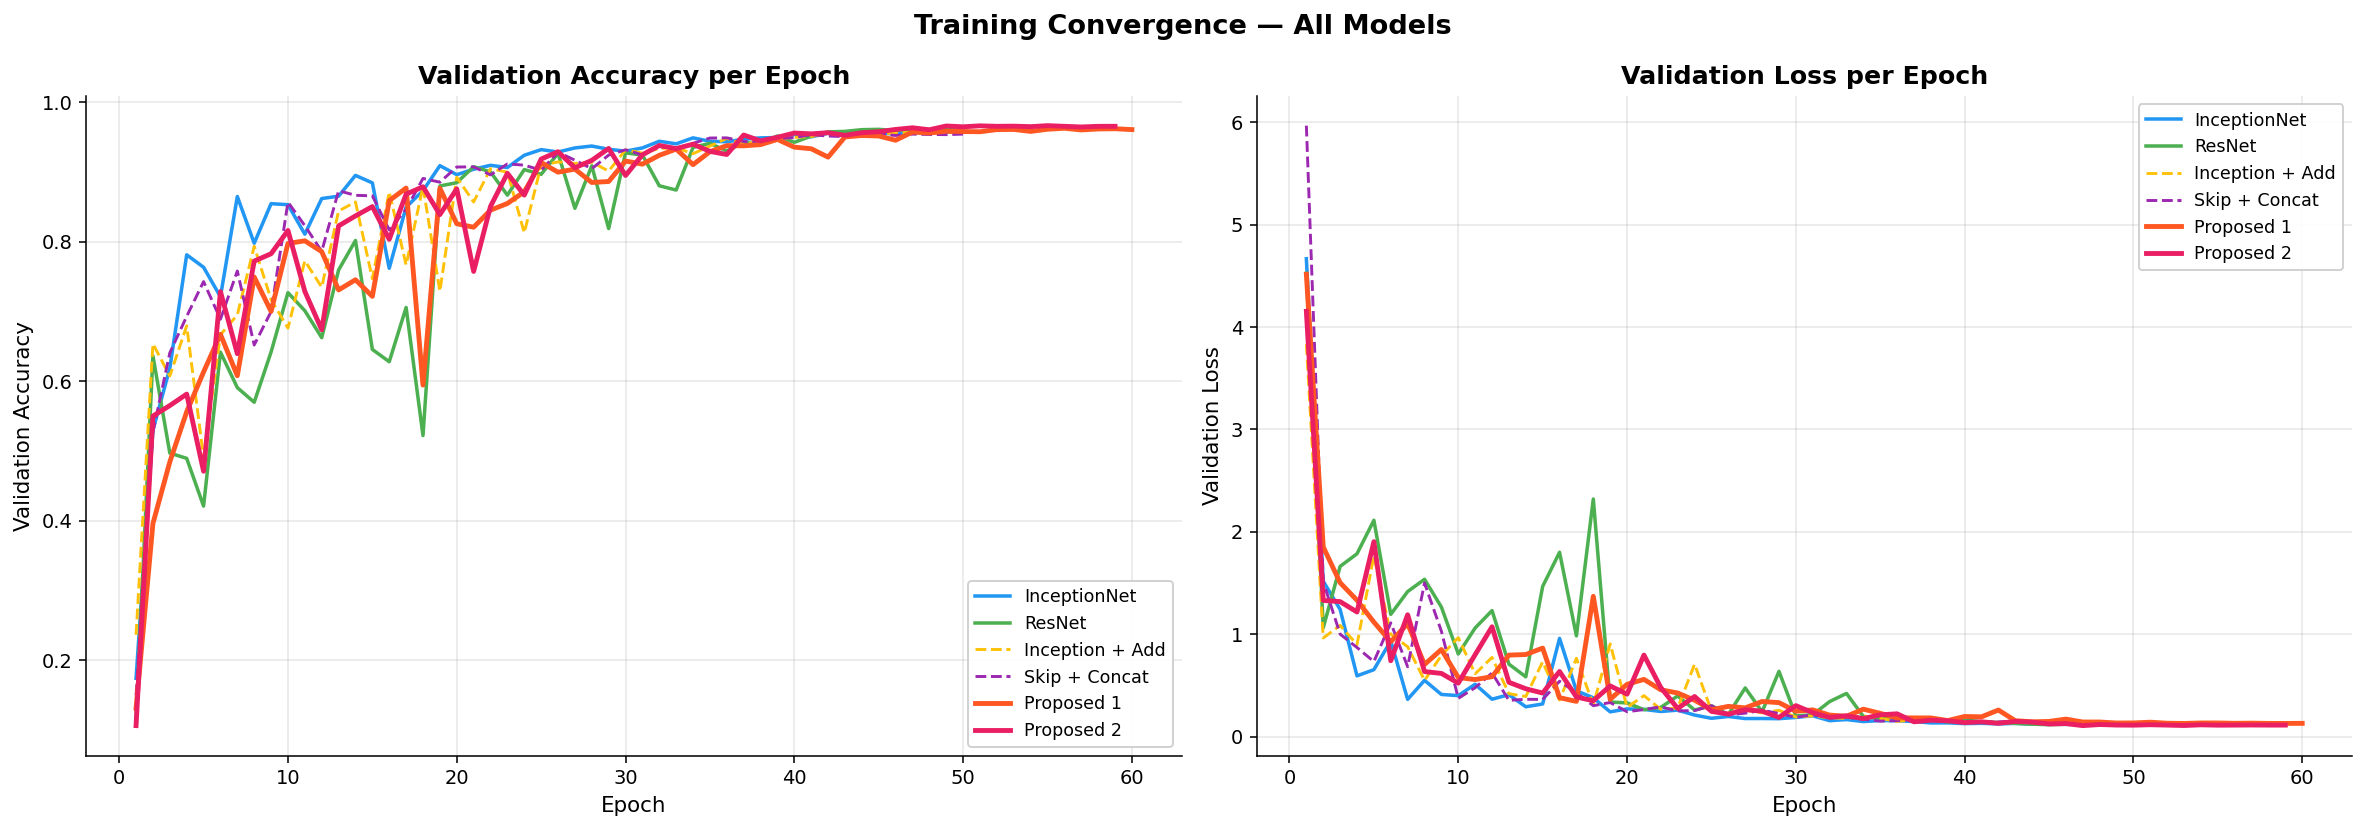

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for fold, nb_id, name, desc, typ in MODELS:
    hp = fpath(fold, 'training_history.csv')
    if not os.path.exists(hp): continue
    df = pd.read_csv(hp)
    ep = df['epoch'] if 'epoch' in df.columns else range(1, len(df)+1)
    clr = color(name); lstyle = ls(typ); lwidth = lw(typ)
    if 'val_accuracy' in df.columns:
        axes[0].plot(ep, df['val_accuracy'], color=clr, lw=lwidth, ls=lstyle, label=name)
    if 'val_loss' in df.columns:
        axes[1].plot(ep, df['val_loss'],     color=clr, lw=lwidth, ls=lstyle, label=name)

for ax, ylabel, title in [
    (axes[0],'Validation Accuracy','Validation Accuracy per Epoch'),
    (axes[1],'Validation Loss',    'Validation Loss per Epoch'),
]:
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)

legend_elems = [
    Line2D([0],[0],color='gray',lw=2.5,ls='-', label='Baseline / Proposed'),
    Line2D([0],[0],color='gray',lw=1.8,ls='--',label='Ablation'),
]
axes[0].legend(fontsize=9); axes[1].legend(fontsize=9)
plt.suptitle('Training Convergence — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'convergence.png'), dpi=140, bbox_inches='tight')
plt.show()


## 8 · Efficiency — Accuracy vs Parameters vs Training Time


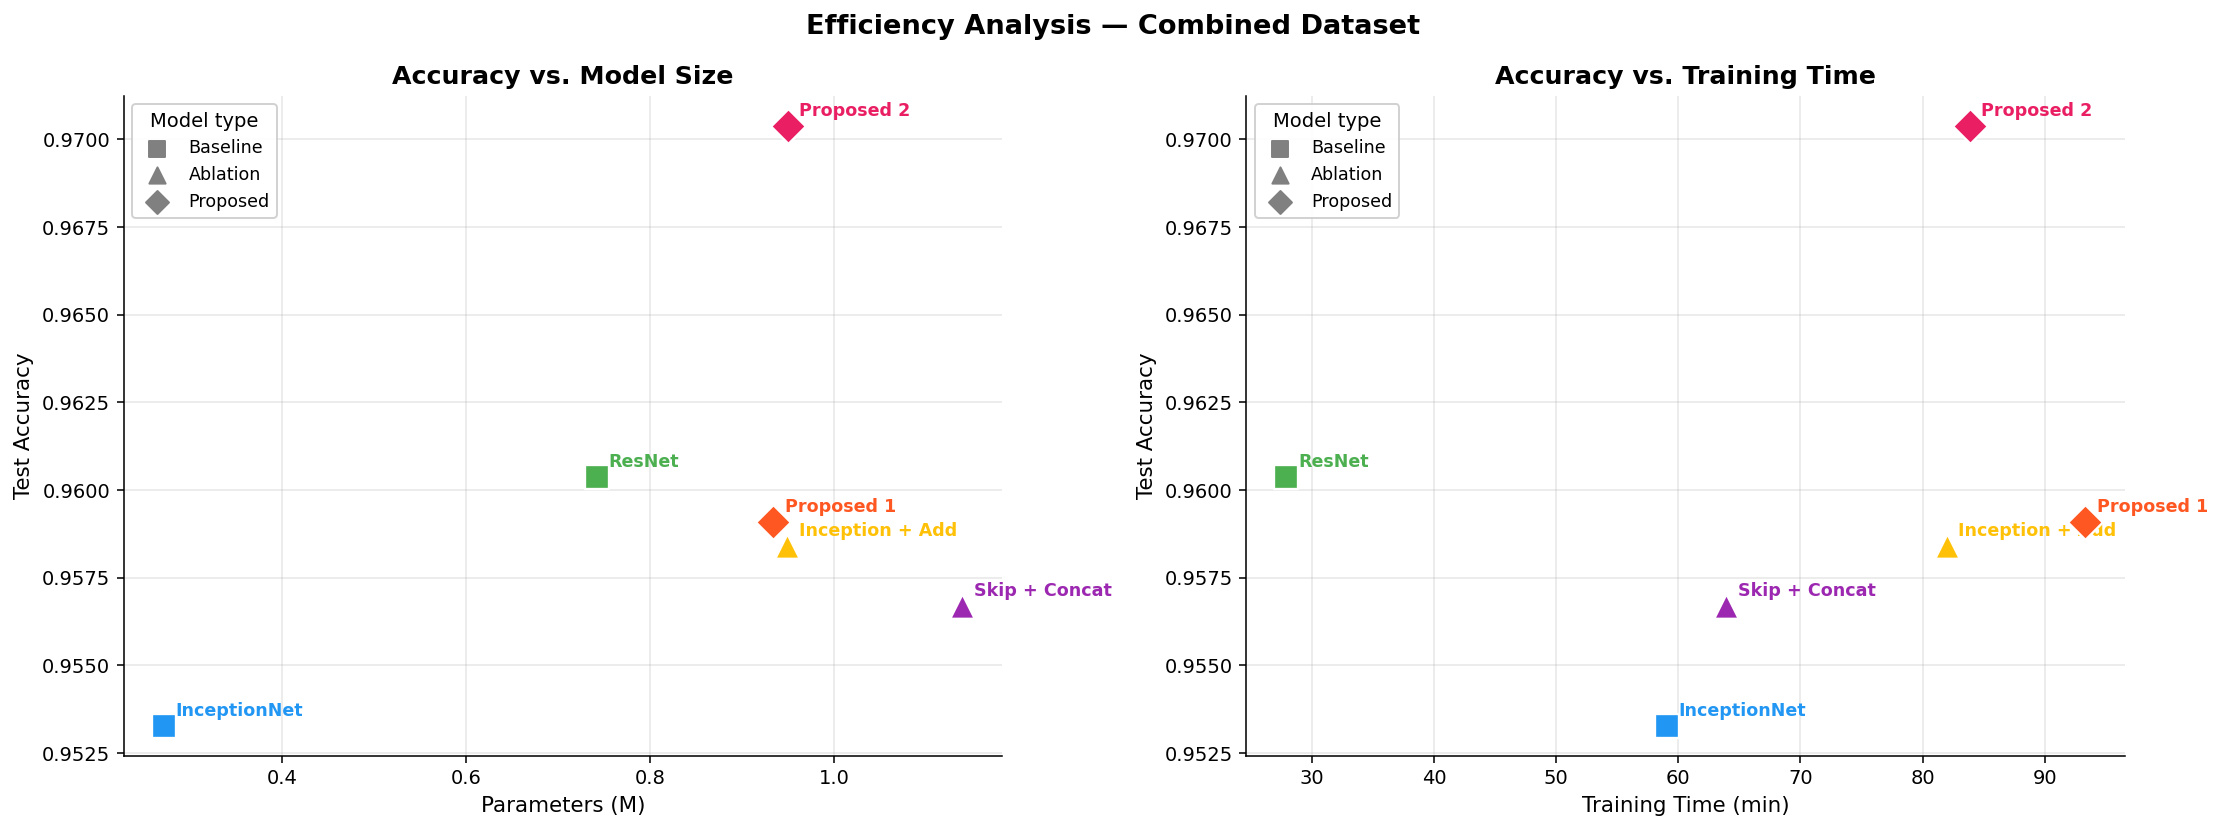

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for _, row in metrics.iterrows():
    name  = row['name']; typ = row['type']
    acc   = row.get('accuracy', 0)
    par   = row.get('params', 0)/1e6 if pd.notna(row.get('params')) else 0
    ttime = row.get('train_time_min', 0) if pd.notna(row.get('train_time_min')) else 0
    clr   = color(name); mk = marker(typ)
    lwidth = 2.5 if typ=='Proposed' else 1.2

    axes[0].scatter(par, acc, s=160, color=clr, marker=mk, zorder=5,
                    edgecolors='white', linewidths=1.2)
    axes[0].annotate(name, (par, acc), xytext=(6,5), textcoords='offset points',
                     fontsize=9, color=clr, fontweight='bold')
    if ttime:
        axes[1].scatter(ttime, acc, s=160, color=clr, marker=mk, zorder=5,
                        edgecolors='white', linewidths=1.2)
        axes[1].annotate(name, (ttime, acc), xytext=(6,5), textcoords='offset points',
                         fontsize=9, color=clr, fontweight='bold')

for ax, xl, tit in [
    (axes[0],'Parameters (M)',     'Accuracy vs. Model Size'),
    (axes[1],'Training Time (min)','Accuracy vs. Training Time'),
]:
    ax.set_xlabel(xl); ax.set_ylabel('Test Accuracy')
    ax.set_title(tit, fontweight='bold'); ax.grid(alpha=0.3)

leg = [plt.scatter([],[],marker=mk,c='gray',s=70,label=t) for t,mk in MARKERS.items()]
axes[0].legend(handles=leg, fontsize=9, title='Model type')
axes[1].legend(handles=leg, fontsize=9, title='Model type')

plt.suptitle('Efficiency Analysis — Combined Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'efficiency.png'), dpi=140, bbox_inches='tight')
plt.show()


## 9 · Per-Class F1-Score Heatmap (All 24 Classes)


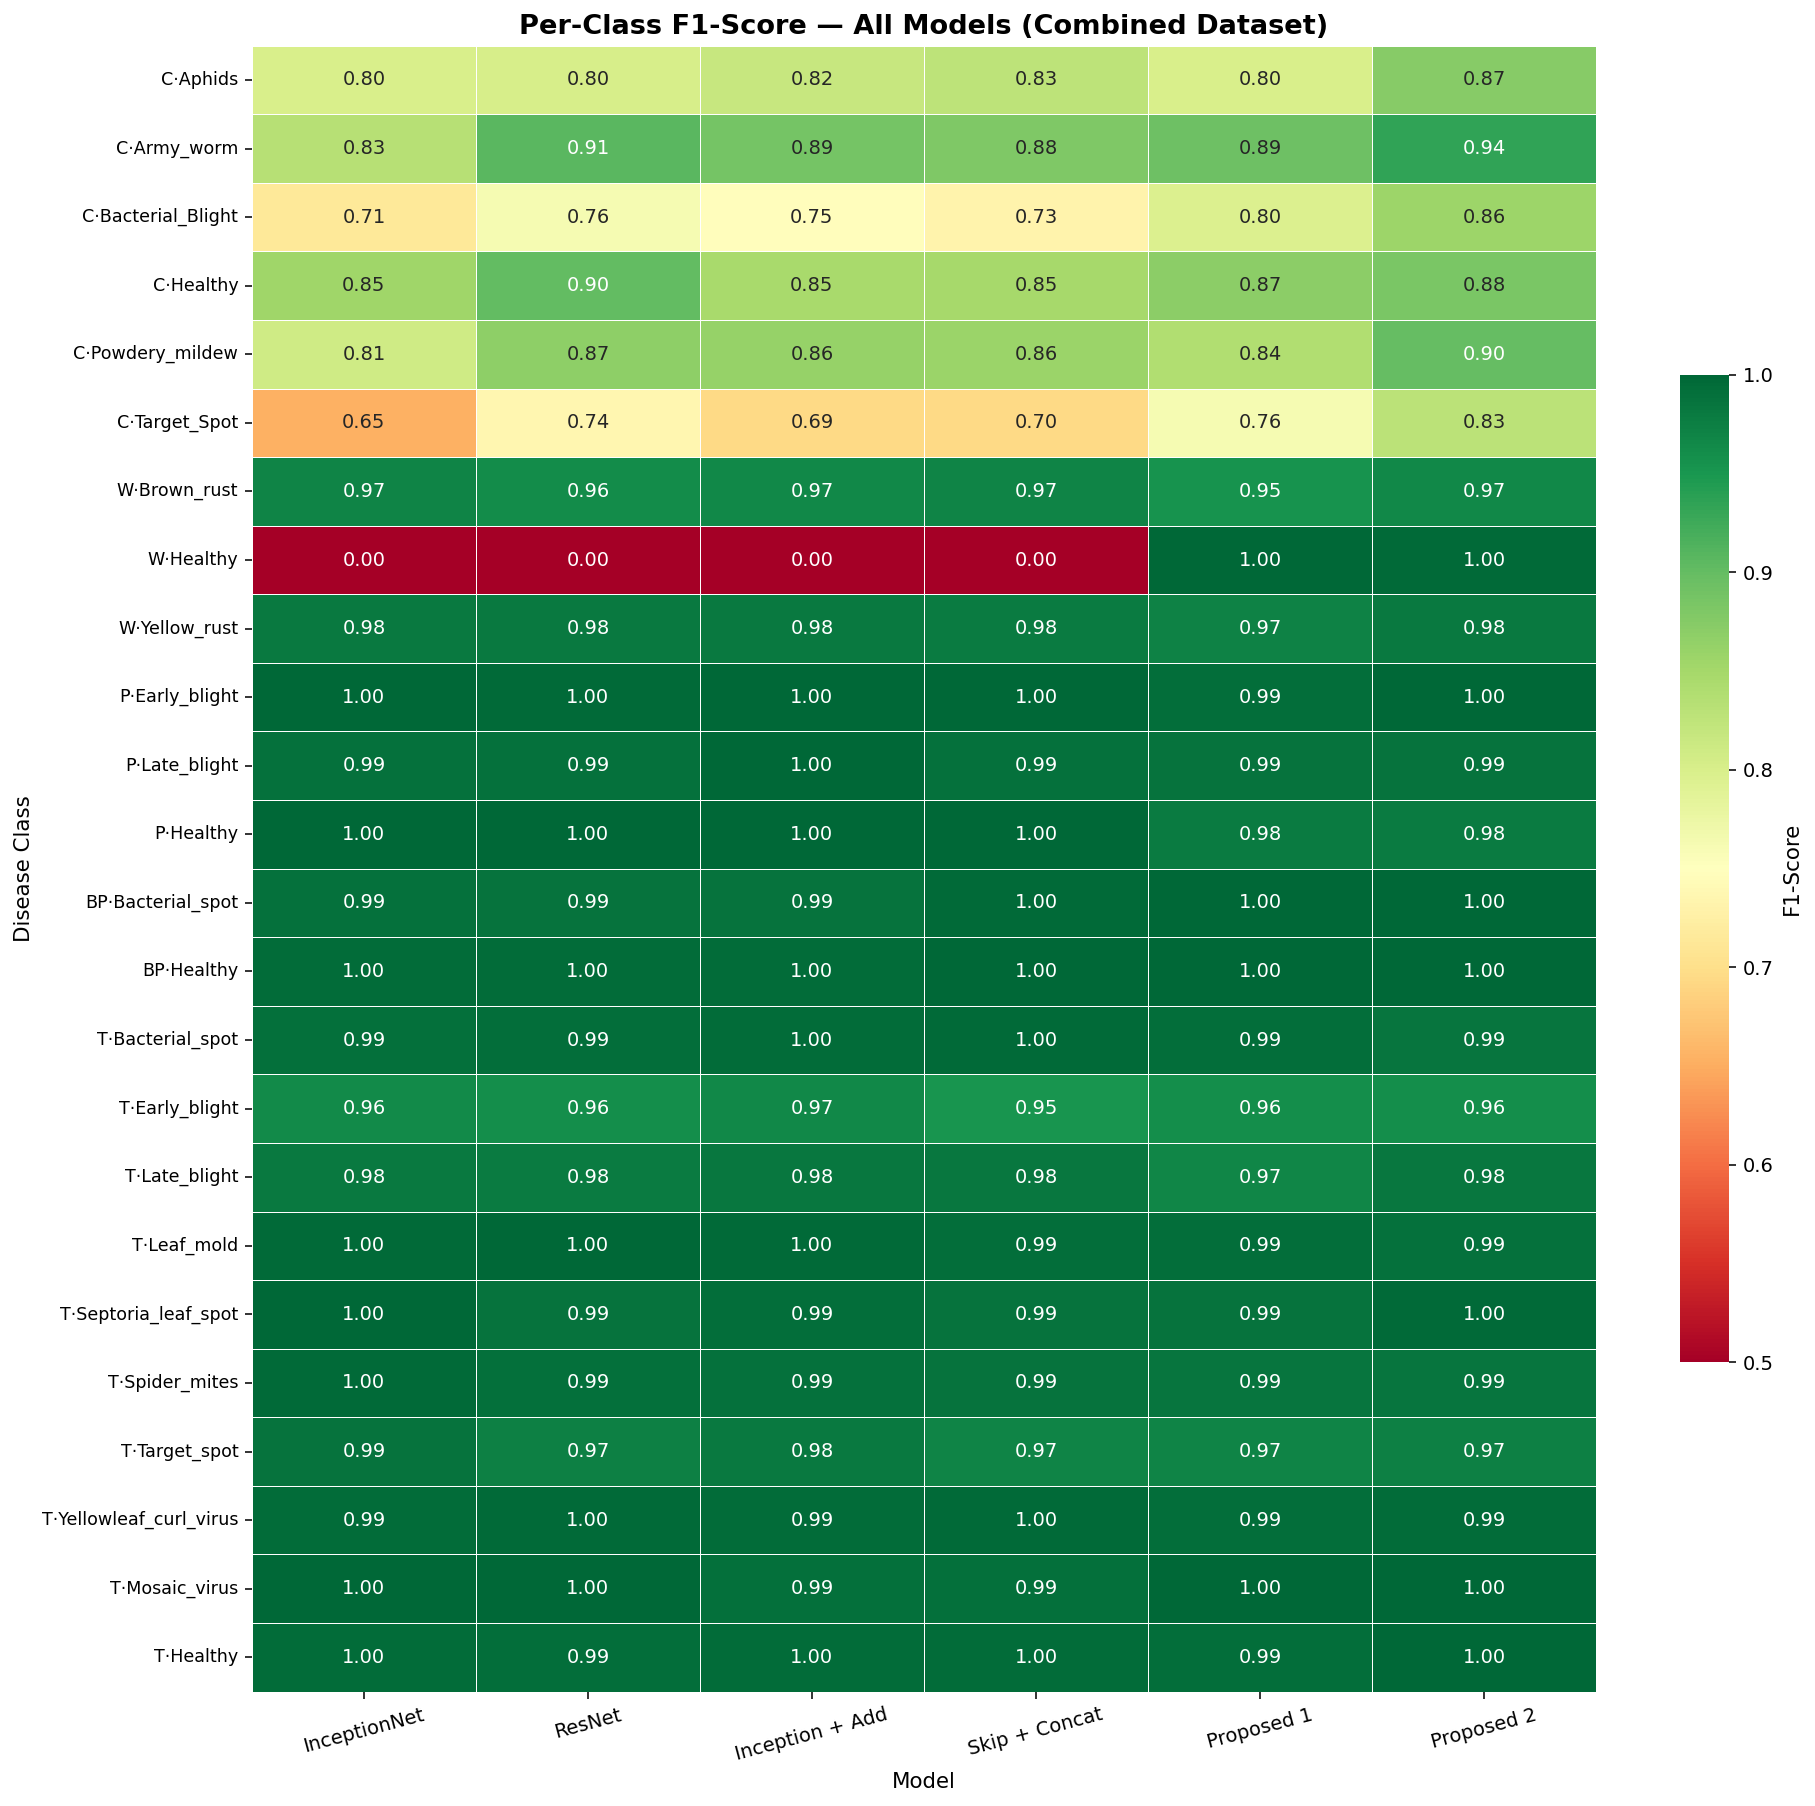

In [12]:
TARGET_CLASSES = [
    'Cotton_Aphids','Cotton_Army_worm','Cotton_Bacterial_Blight','Cotton_Healthy',
    'Cotton_Powdery_mildew','Cotton_Target_Spot','Wheat_Brown_rust','Wheat_Healthy',
    'Wheat_Yellow_rust','Potato_Early_blight','Potato_Late_blight','Potato_Healthy',
    'Bell_Pepper_Bacterial_spot','Bell_Pepper_Healthy','Tomato_Bacterial_spot',
    'Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_mold',
    'Tomato_Septoria_leaf_spot','Tomato_Spider_mites','Tomato_Target_spot',
    'Tomato_Yellowleaf_curl_virus','Tomato_Mosaic_virus','Tomato_Healthy',
]
SHORT = [c.replace('Cotton_','C·').replace('Wheat_','W·').replace('Potato_','P·')
          .replace('Bell_Pepper_','BP·').replace('Tomato_','T·') for c in TARGET_CLASSES]

heat = {}
for fold, nb_id, name, desc, typ in MODELS:
    fp = fpath(fold, 'per_class_metrics.csv')
    if not os.path.exists(fp): continue
    df = pd.read_csv(fp).set_index('class')
    heat[name] = [df.loc[c,'f1'] if c in df.index else np.nan for c in TARGET_CLASSES]

heat_df = pd.DataFrame(heat, index=SHORT)

fig, ax = plt.subplots(figsize=(len(heat)*2+2, 13))
sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0, linewidths=0.4, linecolor='white',
            ax=ax, cbar_kws={'label':'F1-Score','shrink':0.6})
ax.set_title('Per-Class F1-Score — All Models (Combined Dataset)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Model'); ax.set_ylabel('Disease Class')
ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'per_class_f1_heatmap.png'), dpi=140, bbox_inches='tight')
plt.show()


## 10 · Hard Classes Spotlight — Cotton & Wheat


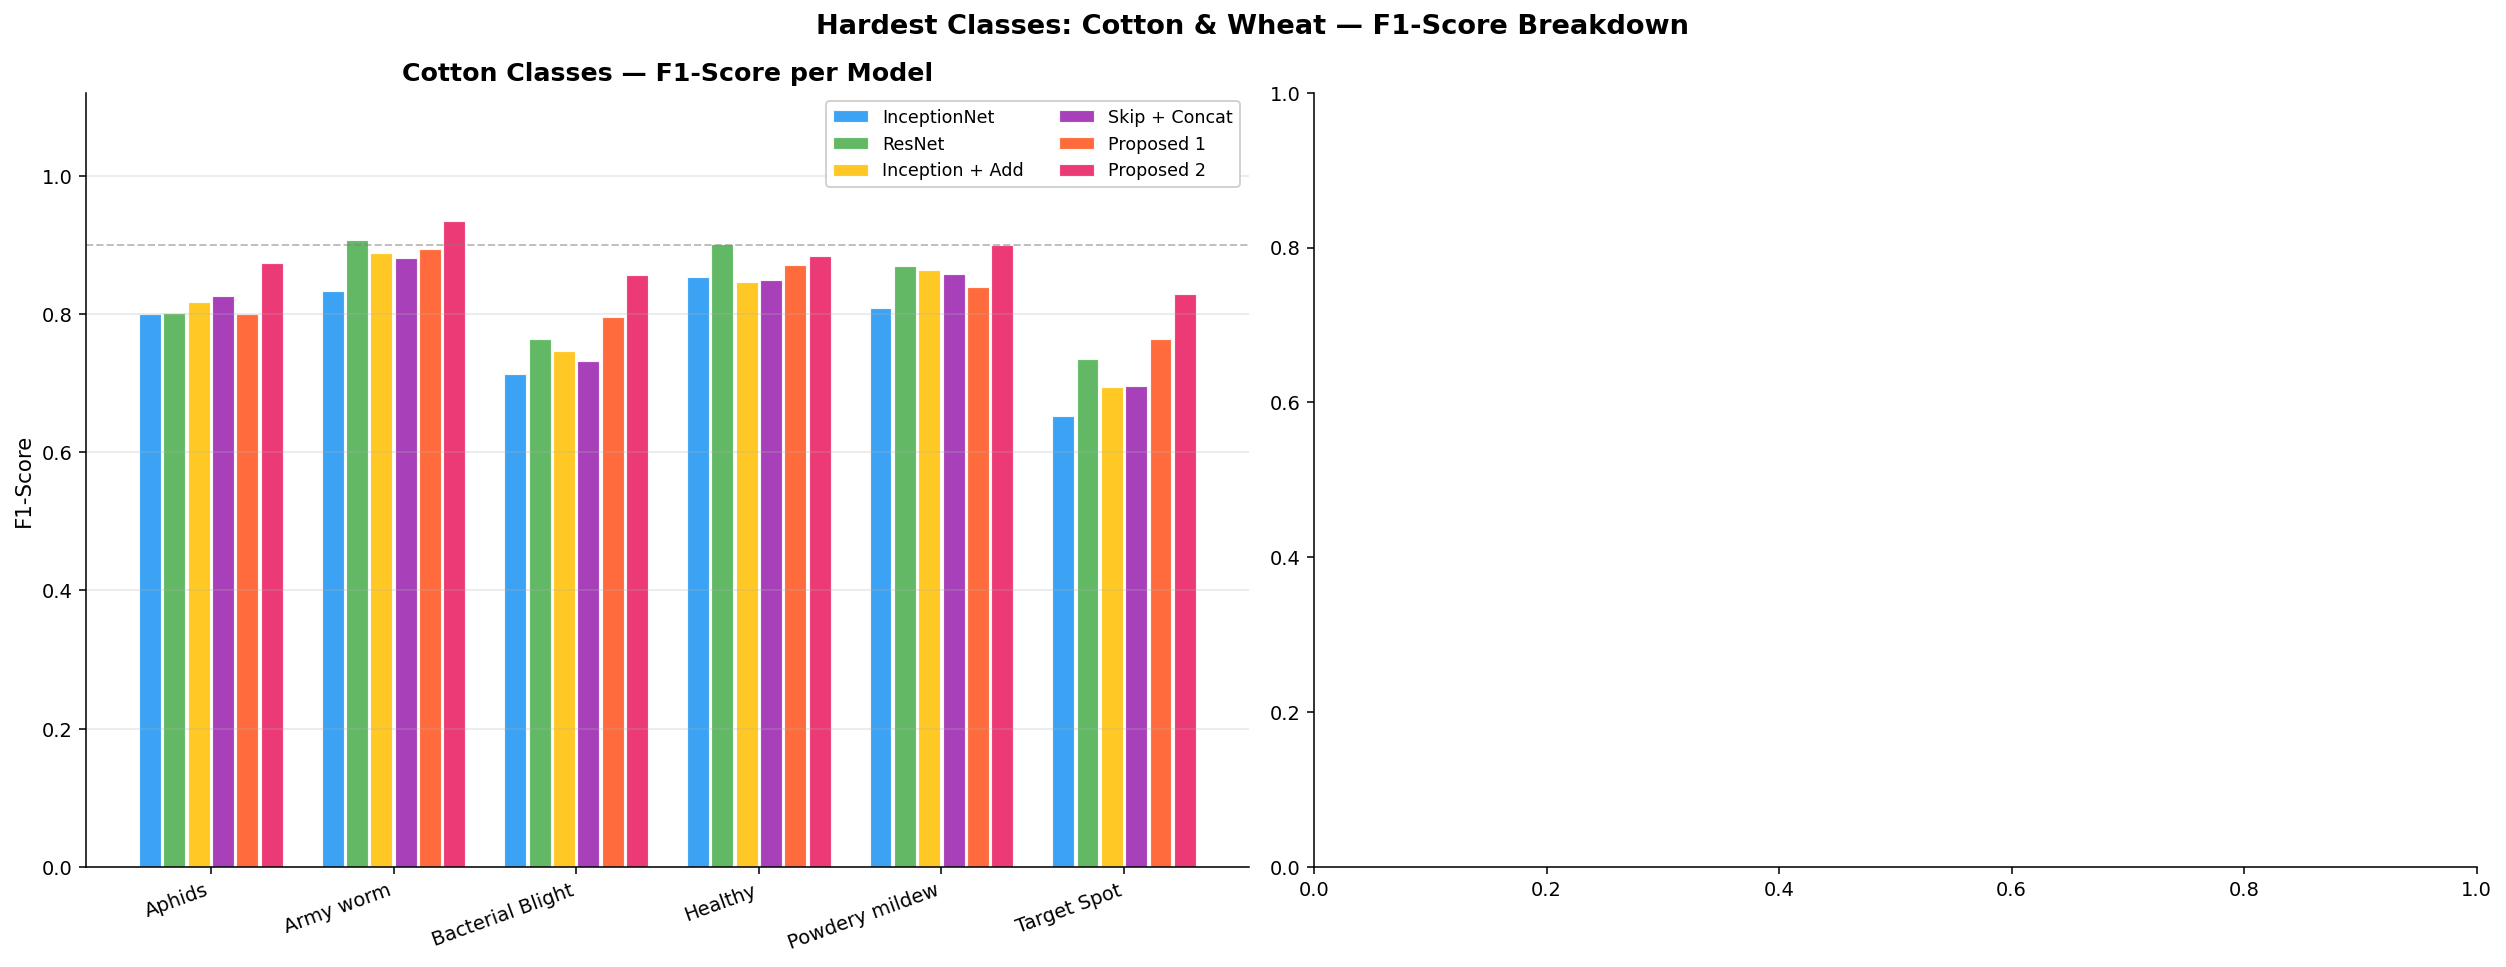

In [18]:
COTTON = ['Cotton_Aphids','Cotton_Army_worm','Cotton_Bacterial_Blight',
          'Cotton_Healthy','Cotton_Powdery_mildew','Cotton_Target_Spot']
WHEAT  = ['Wheat_Brown_rust','Wheat_Healthy','Wheat_Yellow_rust']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, cls_group, grp_title in [
    (axes[0], COTTON, 'Cotton Classes — F1-Score per Model'),
]:
    n_models = len(MODELS); n_cls = len(cls_group)
    w = 0.8/n_models
    for mi, (fold, nb_id, name, desc, typ) in enumerate(MODELS):
        fp = fpath(fold, 'per_class_metrics.csv')
        if not os.path.exists(fp): continue
        df = pd.read_csv(fp).set_index('class')
        vals = [df.loc[c,'f1'] if c in df.index else 0 for c in cls_group]
        x = np.arange(n_cls) + mi*w - (n_models-1)*w/2
        bars = ax.bar(x, vals, w*0.9, color=color(name), label=name,
                      alpha=0.88, edgecolor='white', linewidth=0.6)
    ax.set_xticks(np.arange(n_cls))
    ax.set_xticklabels([c.split('_',1)[-1].replace('_',' ') for c in cls_group],
                       rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 1.12); ax.set_ylabel('F1-Score')
    ax.set_title(grp_title, fontweight='bold'); ax.legend(fontsize=9, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(0.9, color='gray', ls='--', lw=1, alpha=0.5, label='0.90 threshold')

plt.suptitle('Hardest Classes: Cotton & Wheat — F1-Score Breakdown',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'hard_classes.png'), dpi=140, bbox_inches='tight')
plt.show()


## 11 · Composite Ranking


Scoring weights: {'accuracy': 0.3, 'f1': 0.2, 'macro_auc': 0.25, 'specificity': 0.15, 'param_eff': 0.05, 'conv_speed': 0.05}

=== Composite Ranking ===
 Rank           Model     Type  Accuracy       F1  Macro AUC  Specificity  Param Eff  Conv Speed  Composite Score
    1      Proposed 2 Proposed  0.970395 0.970440   0.999452     0.998721      0.506       0.068          0.91355
    2      Proposed 1 Proposed  0.959100 0.959100   0.962900     0.998200      0.507       0.067          0.89871
    3    InceptionNet Baseline  0.953278 0.953158        NaN     0.997984      0.642       0.040              NaN
    4          ResNet Baseline  0.960372 0.960184        NaN     0.998288      0.532       0.100              NaN
    5 Inception + Add Ablation  0.958415 0.958238        NaN     0.998204      0.506       0.060              NaN
    6   Skip + Concat Ablation  0.956703 0.956692        NaN     0.998130      0.486       0.100              NaN


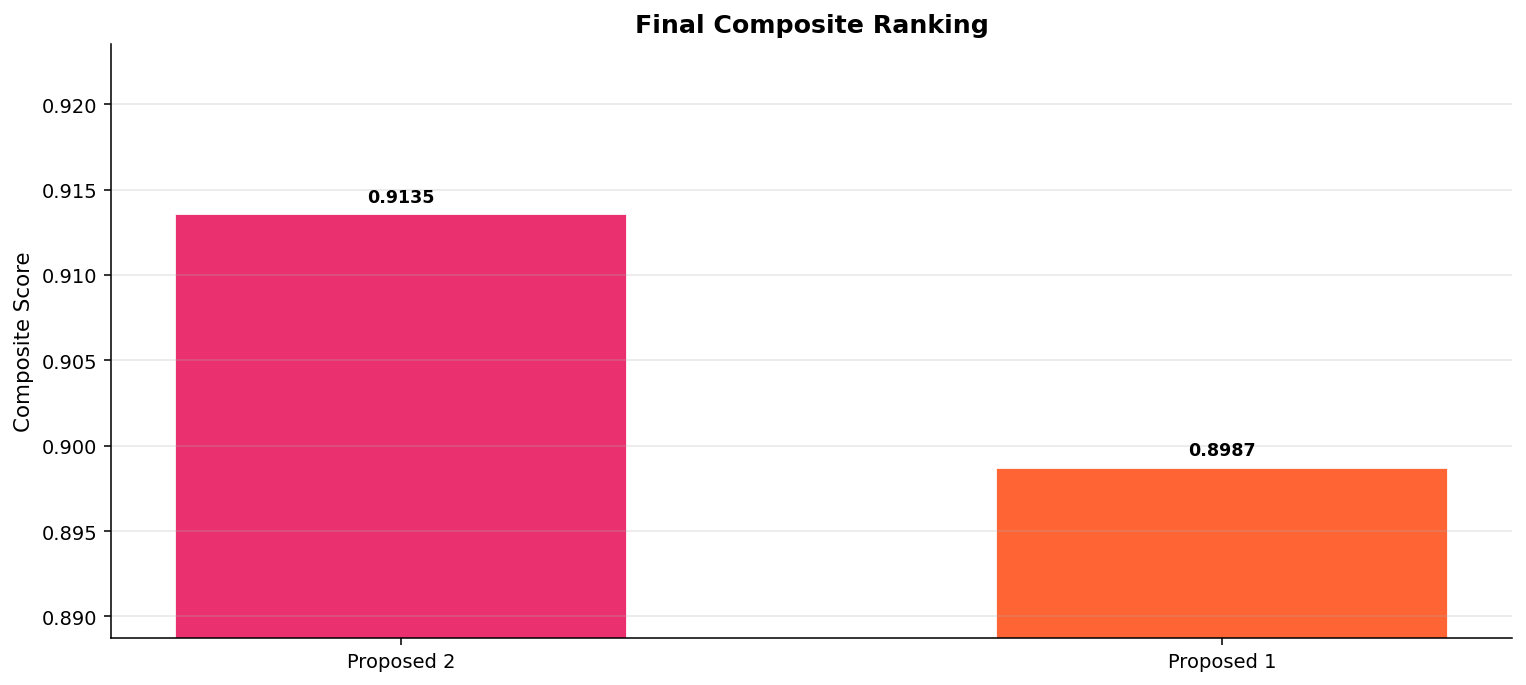

In [14]:
# Load macro AUC for each model (computed from y_prob above)
WEIGHTS = {
    'accuracy':     0.30,
    'f1':           0.20,
    'macro_auc':    0.25,
    'specificity':  0.15,
    'param_eff':    0.05,
    'conv_speed':   0.05,
}
print(f"Scoring weights: {WEIGHTS}\n")

score_rows = []
for fold, nb_id, name, desc, typ in MODELS:
    row = metrics[metrics['name']==name]
    if row.empty: continue
    row = row.iloc[0]
    acc  = row.get('accuracy',0)
    f1   = row.get('f1',0)
    spec = row.get('specificity',0)
    par  = row.get('params',1e9)
    # macro AUC from roc_df if available
    if 'roc_df' in dir() and name in roc_df['Model'].values:
        mac = roc_df[roc_df['Model']==name]['Macro_AUC'].values[0]
    else:
        mac = row.get('best_val_acc', acc)
    # Param efficiency: log10 scale, 100K→0.9, 1M→0.67, 10M→0.33
    pe = max(0, 1 - (np.log10(max(par,1e4))-4)/4)
    # Convergence speed from history
    hp = fpath(fold,'training_history.csv')
    if os.path.exists(hp):
        hdf = pd.read_csv(hp)
        best_ep = hdf['val_accuracy'].idxmax()+1
        cs = 1 - best_ep/len(hdf)
    else: cs=0.5
    total = (acc*WEIGHTS['accuracy'] + f1*WEIGHTS['f1'] + mac*WEIGHTS['macro_auc'] +
             spec*WEIGHTS['specificity'] + pe*WEIGHTS['param_eff'] + cs*WEIGHTS['conv_speed'])
    score_rows.append({'Model':name,'Type':typ,'Accuracy':acc,'F1':f1,
                       'Macro AUC':mac,'Specificity':spec,'Param Eff':round(pe,3),
                       'Conv Speed':round(cs,3),'Composite Score':round(total,5)})

score_df = pd.DataFrame(score_rows).sort_values('Composite Score',ascending=False).reset_index(drop=True)
score_df.insert(0,'Rank',range(1,len(score_df)+1))
print("=== Composite Ranking ===")
print(score_df.to_string(index=False))
score_df.to_csv(os.path.join(SAVE_DIR,'composite_ranking.csv'), index=False)

fig, ax = plt.subplots(figsize=(11,5))
clrs_ = [color(m) for m in score_df['Model']]
bars  = ax.bar(score_df['Model'], score_df['Composite Score'],
               color=clrs_, edgecolor='white', width=0.55, alpha=0.92)
for bar, v in zip(bars, score_df['Composite Score']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(score_df['Composite Score'].min()-0.01, score_df['Composite Score'].max()+0.01)
ax.set_ylabel('Composite Score'); ax.set_title('Final Composite Ranking', fontweight='bold')
ax.grid(True,axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'composite_ranking.png'),dpi=140,bbox_inches='tight')
plt.show()


## 12 · Summary Dashboard & Final Verdict


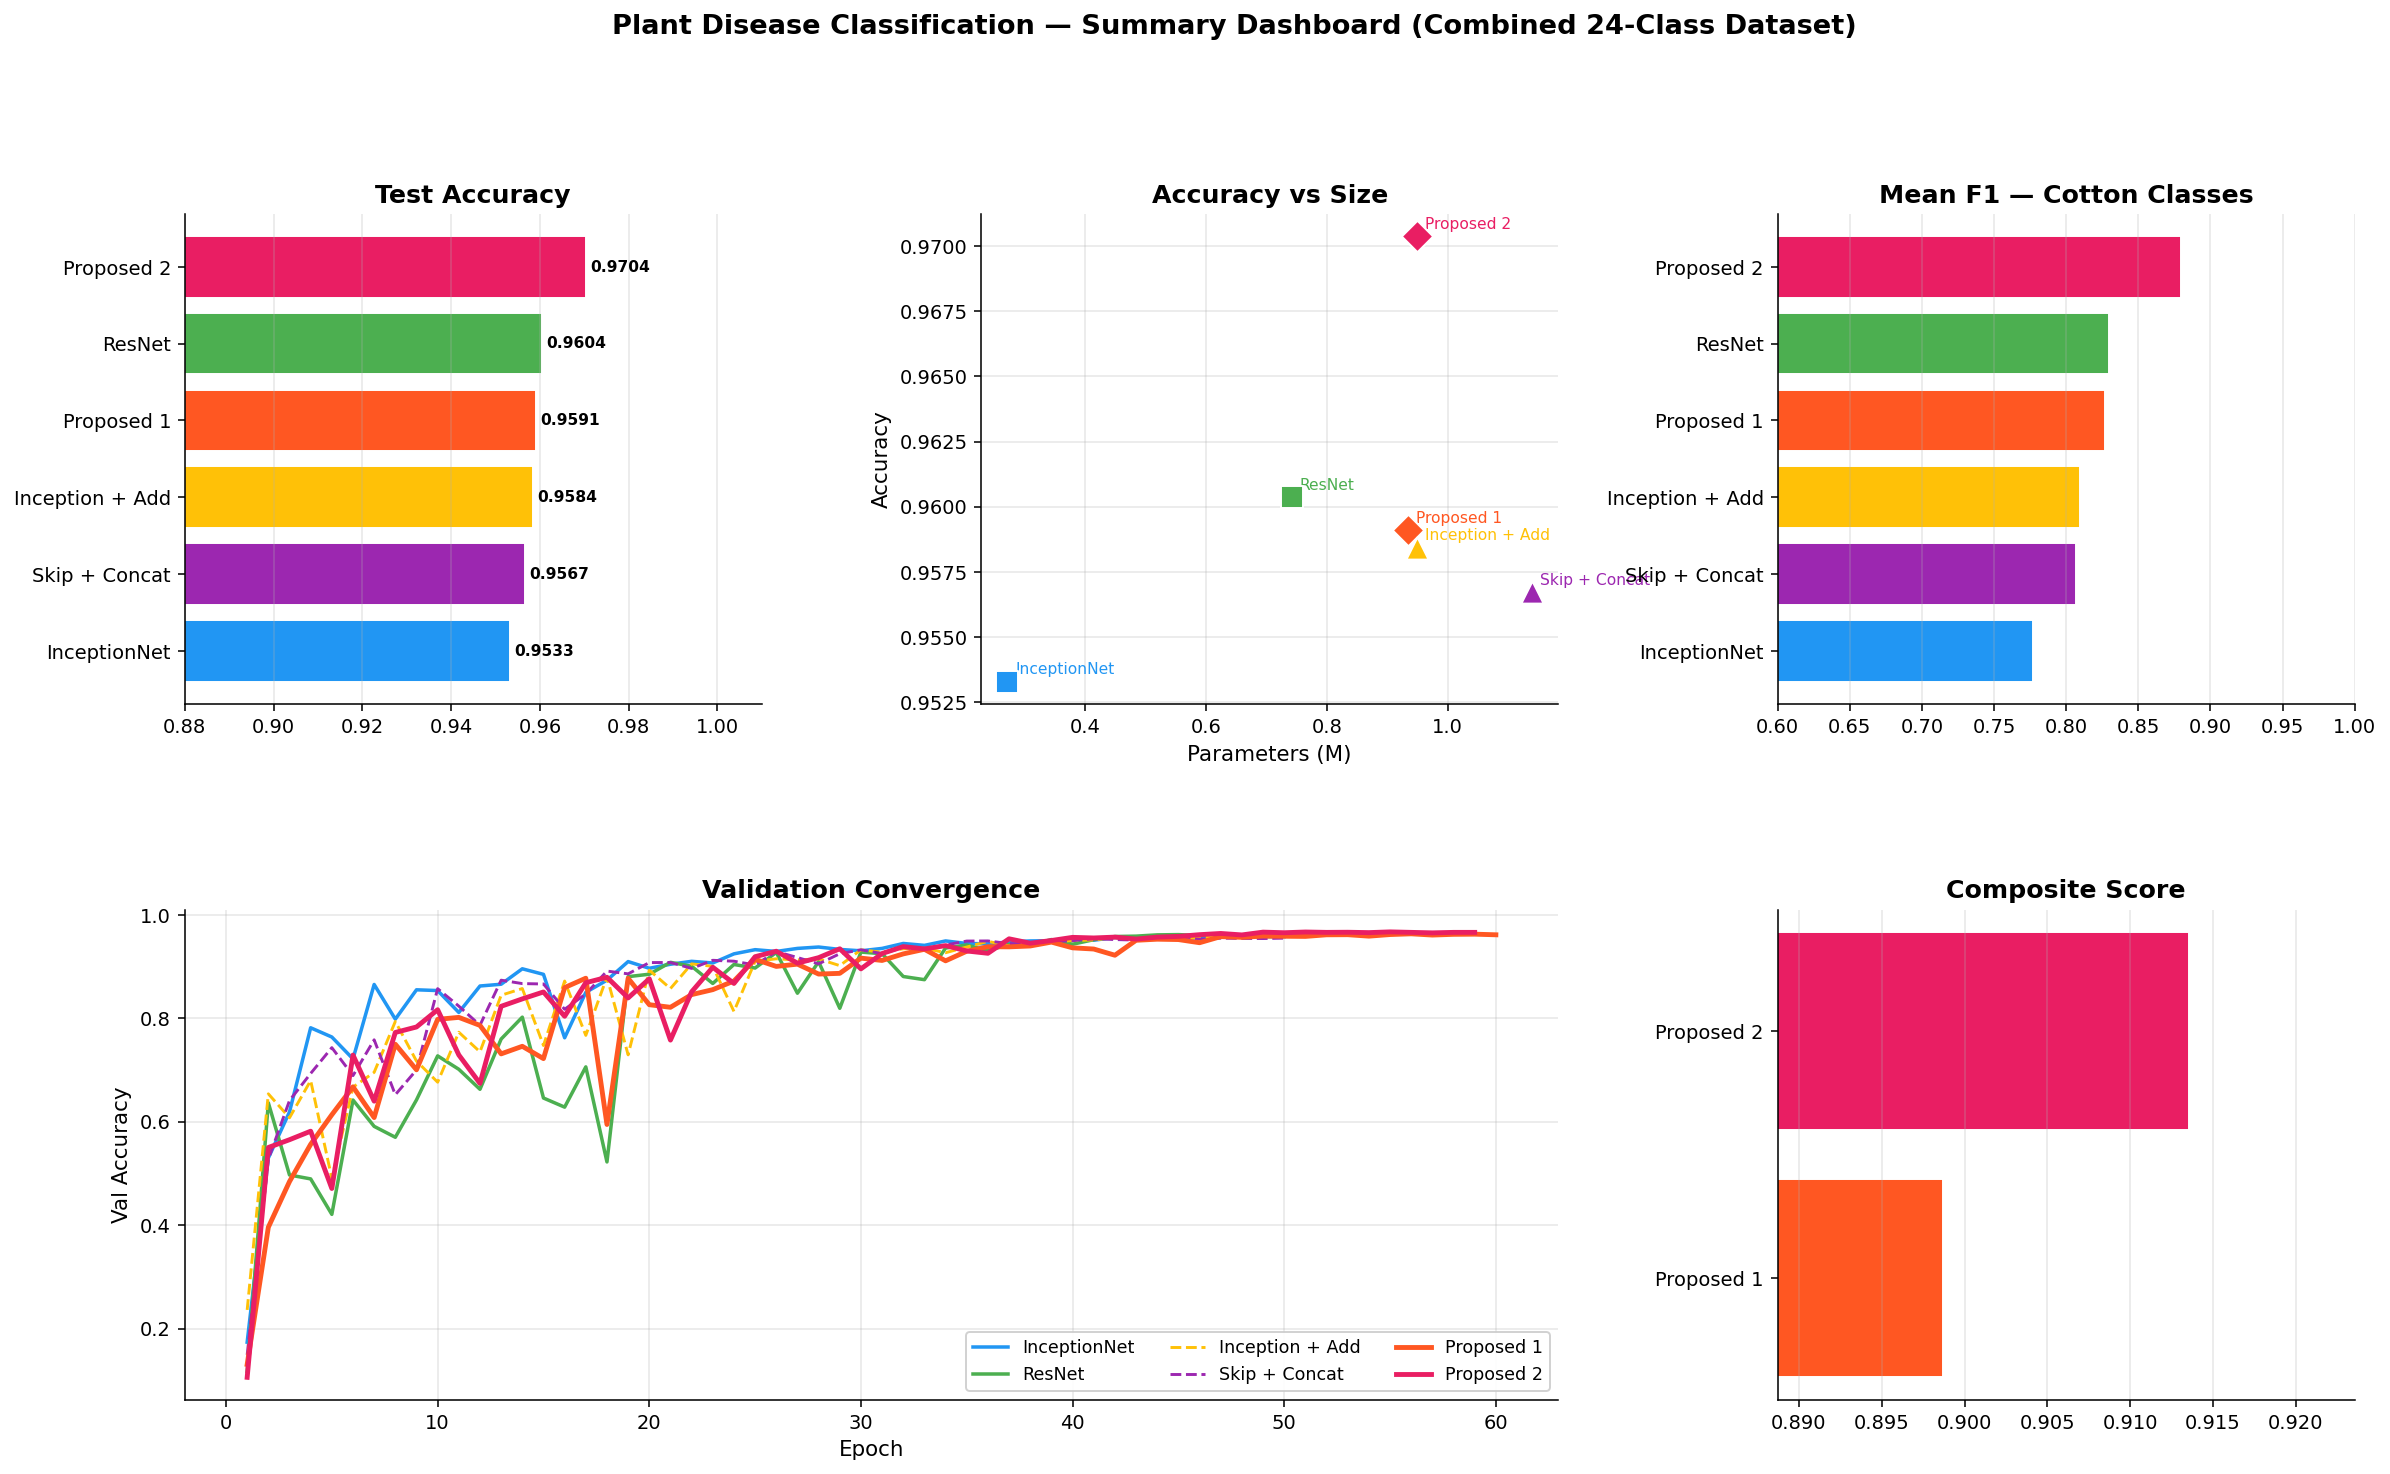


All outputs saved to: /kaggle/working/comparison_outputs


In [15]:
fig = plt.figure(figsize=(20,11))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.42,wspace=0.38)

# ── Panel 1: Accuracy bar ──
ax1 = fig.add_subplot(gs[0,0])
mets_sorted = metrics.sort_values('accuracy')
clrs_ = [color(n) for n in mets_sorted['name']]
bars  = ax1.barh(mets_sorted['name'], mets_sorted['accuracy'], color=clrs_, edgecolor='white')
for bar,v in zip(bars,mets_sorted['accuracy']):
    ax1.text(bar.get_width()+0.001,bar.get_y()+bar.get_height()/2,
             f'{v:.4f}',va='center',fontsize=8,fontweight='bold')
ax1.set_xlim(0.88,1.01); ax1.set_title('Test Accuracy',fontweight='bold')
ax1.grid(True,axis='x',alpha=0.3)

# ── Panel 2: Params vs Accuracy ──
ax2 = fig.add_subplot(gs[0,1])
for _,row in metrics.iterrows():
    ax2.scatter(row.get('params',0)/1e6,row.get('accuracy',0),
                s=130,color=color(row['name']),marker=marker(row['type']),
                zorder=5,edgecolors='white',linewidths=1)
    ax2.annotate(row['name'],(row.get('params',0)/1e6,row.get('accuracy',0)),
                 xytext=(4,4),textcoords='offset points',fontsize=8,color=color(row['name']))
ax2.set_xlabel('Parameters (M)'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Size',fontweight='bold'); ax2.grid(alpha=0.3)

# ── Panel 3: Hard classes (Cotton F1) ──
ax3 = fig.add_subplot(gs[0,2])
cotton_f1_means = []
for fold,nb_id,name,desc,typ in MODELS:
    fp = fpath(fold,'per_class_metrics.csv')
    if not os.path.exists(fp): continue
    df = pd.read_csv(fp).set_index('class')
    vals=[df.loc[c,'f1'] if c in df.index else 0 for c in COTTON]
    cotton_f1_means.append({'name':name,'mean_cotton_f1':np.mean(vals),'color':color(name)})
cdf=pd.DataFrame(cotton_f1_means).sort_values('mean_cotton_f1')
ax3.barh(cdf['name'],cdf['mean_cotton_f1'],color=cdf['color'].tolist(),edgecolor='white')
ax3.set_xlim(0.6,1.0); ax3.set_title('Mean F1 — Cotton Classes',fontweight='bold')
ax3.grid(True,axis='x',alpha=0.3)

# ── Panel 4: Convergence ──
ax4=fig.add_subplot(gs[1,0:2])
for fold,nb_id,name,desc,typ in MODELS:
    hp=fpath(fold,'training_history.csv')
    if not os.path.exists(hp): continue
    df=pd.read_csv(hp); ep=df['epoch'] if 'epoch' in df.columns else range(1,len(df)+1)
    if 'val_accuracy' in df.columns:
        ax4.plot(ep,df['val_accuracy'],color=color(name),lw=lw(typ),ls=ls(typ),label=name)
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Val Accuracy')
ax4.set_title('Validation Convergence',fontweight='bold')
ax4.legend(fontsize=9,ncol=3); ax4.grid(alpha=0.3)

# ── Panel 5: Composite scores ──
ax5=fig.add_subplot(gs[1,2])
sd2=score_df.sort_values('Composite Score',ascending=True)
clrs_=[color(m) for m in sd2['Model']]
ax5.barh(sd2['Model'],sd2['Composite Score'],color=clrs_,edgecolor='white')
ax5.set_title('Composite Score',fontweight='bold')
ax5.set_xlim(sd2['Composite Score'].min()-0.01,sd2['Composite Score'].max()+0.01)
ax5.grid(True,axis='x',alpha=0.3)

fig.suptitle('Plant Disease Classification — Summary Dashboard (Combined 24-Class Dataset)',
             fontsize=14,fontweight='bold',y=1.01)
plt.savefig(os.path.join(SAVE_DIR,'summary_dashboard.png'),dpi=140,bbox_inches='tight')
plt.show()
print("\nAll outputs saved to:", SAVE_DIR)


In [16]:
print("=== Files generated ===")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"  {f}  ({os.path.getsize(os.path.join(SAVE_DIR,f))//1024} KB)")
import shutil
shutil.make_archive('/kaggle/working/combined_comparison', 'zip', SAVE_DIR)
print("\nZip → /kaggle/working/combined_comparison.zip")


=== Files generated ===
  accuracy_f1.png  (104 KB)
  composite_ranking.csv  (0 KB)
  composite_ranking.png  (34 KB)
  convergence.png  (229 KB)
  efficiency.png  (84 KB)
  hard_classes.png  (103 KB)
  metrics_master.csv  (1 KB)
  per_class_f1_heatmap.png  (225 KB)
  prec_rec_spec.png  (99 KB)
  radar.png  (218 KB)
  roc_auc_summary.csv  (0 KB)
  roc_comparison.png  (111 KB)
  summary_dashboard.png  (236 KB)

Zip → /kaggle/working/combined_comparison.zip
